# 시계열 예측 기술의 변화

HD현대중공업에 제출하는 내용으로 3년(2023–2026) 사이 시계열 예측(Time Series Forecasting, TSF) 분야의 기술 변화를 요약하였다. 최근 시계열 데이터 분석 모델은 단순히 과거의 데이터를 기반으로 미래를 예측하는 것이 아닌, 데이터의 기하학적 구조, 변수 간의 복잡한 상호작용, 그리고 물리적 법칙의 내재화라는 방향으로 전환되고 있다. ICLR, NeurIPS, ICML, AAAI, KDD와 같은 최상위 인공지능 학회를 중심으로 발표된 연구들은 시계열 데이터를 처리하는 기본 단위부터 최적화 방식에 이르기까지 근본적인 재검토를 요구하고 있다.[1] 본 보고서는 이러한 기술적 흐름을 분석하고, 특히 선박 운항과 같이 높은 안전성이 요구되는 자율 운항 분야에서의 적용 가능성을 서술하였다.

## 1. Transformer 아키텍처의 재구성: PatchTST와 iTransformer를 중심으로

시계열 예측 분야에서 Transformer의 위상은 2023년을 기점으로 변화하였다. 초기 Transformer 모델들이 자연어 처리(NLP)의 점진적 토큰화 방식을 그대로 차용하면서 나타났던 연산 효율성 문제와 국소적 의미 망각 문제는 새로운 아키텍처의 등장과 함께 완화되기 시작하였다.[3]

### 1.1 PatchTST: 시계열을 64개의 단어로 해석

PatchTST는 시계열 데이터를 개별 시점(point-wise)이 아닌 패치(patch) 단위로 분할하여 처리하는 접근법을 제시하였다. 기존 Transformer 기반 모델들이 각 시점의 스칼라 값을 하나의 토큰으로 취급함으로써 어텐션 맵의 크기가 시퀀스 길이 $L$의 제곱에 비례하는 $O(L^2)$의 복잡도를 가졌던 것과 달리, PatchTST는 인접한 시점들을 하나의 패치로 묶음으로써 연산 복잡도를 $O((L/P)^2)$로 낮추었다. 여기서 $P$는 패치의 크기다.[3][5]

이러한 패치화 전략은 단순히 연산량만 줄이는 것이 아니라, 시계열 데이터가 가지는 국소적 의미론(local semantics)을 보존하는 데에도 기여한다. 단일 시점은 그 자체로 충분한 정보를 담기 어렵지만, 패치 단위로 묶인 데이터는 추세(trend)나 계절성(seasonality)과 같은 패턴을 더 명확하게 드러낸다.[6] 또한 PatchTST는 마스크된 패치 재구성(masked patch reconstruction) 기반의 자기지도 학습(self-supervised learning)을 도입하여, 레이블이 없는 대규모 시계열 데이터로부터 강건한 표현을 학습할 수 있음을 보였다.[3]

### 1.2 iTransformer: 아키텍처의 반전과 다변수 상관관계의 포착

2024년 발표된 iTransformer는 Transformer 아키텍처를 시공간적으로 반전시킴으로써 다변수 시계열 예측의 새로운 방향을 제시하였다. 기존 모델들이 시간축을 따라 토큰을 생성했던 것과 달리, iTransformer는 각 변수(channel)의 전체 시퀀스를 하나의 토큰으로 취급한다.[4]

이러한 반전된 구조에서 셀프 어텐션 메커니즘은 시간적 의존성이 아닌 변수 간 상관관계(inter-variate correlation)를 학습하게 된다.[4] 한편 시간적 패턴의 학습은 각 토큰별로 적용되는 피드포워드 네트워크(FFN)가 담당하게 되는데, 이는 시계열 데이터의 비정상성(non-stationarity)을 완화하는 데 효과적인 것으로 보고되었다.[4] iTransformer는 특히 기상 데이터와 같이 변수 간 물리적 연관성이 뚜렷한 데이터셋에서 높은 효율성을 보이며 다변수 통합 능력을 입증하였다.[9]

| 비교 항목 | PatchTST | iTransformer |
|---|---|---|
| 토큰 구성 단위 | 시간적 패치 (Temporal Patches) | 변수별 전체 시퀀스 (Variable-wise) |
| 어텐션 대상 | 동일 변수 내 시간적 맥락 | 서로 다른 변수 간 상관관계 |
| 연산 복잡도 | $O((L/P)^2)$ | 대체로 변수 수 $C$에 의존하는 구조 |
| 핵심 장점 | 긴 입력 창(Look-back) 처리 최적화 | 다변수 정보 결합 및 비정상성 대응 |

## 2. Modern CNN: TimesNet과 ModernTCN의 부상

Transformer가 주도하던 TSF 분야에서 CNN 기반 모델들이 현대적인 설계를 도입하며 다시 경쟁력을 확보하였다. 이는 표준 CNN의 한계를 극복하고 시계열 데이터의 고유한 특성을 반영한 결과로 해석할 수 있다.[10]

### 2.1 2D CNN for Multivariate Time Series(예시 2번)

2D CNN for Multivariate Time Series는 다변량 시계열 데이터의 여러 변수를 이미지의 행(Row)처럼 배치하여, 변수 간의 상관관계(Spatial Correlation)와 시간적 흐름(Temporal Dynamics)을 동시에 학습하는 방법이다. 이 방식은 각 피처를 독립적인 채널로 처리하는 1D 기반 방식과 달리, 서로 다른 변수들이 물리적 혹은 논리적으로 인접해 있을 때 발생하는 공간적 특징을 2D 커널을 통해 직접 추출한다.

입력 데이터는 $(N, T)$ 형태의 2차원 격자로 구성되며, 여기서 $N$은 변수의 개수, $T$는 시간의 길이를 의미한다. 2D 컨볼루션 커널은 이 격자 위를 슬라이딩하며 변수들 사이의 국소적 관계와 시간적 패턴을 통합적으로 파악한다. 특히 센서 데이터나 뇌파 분석과 같이 변수 간의 위치 관계가 중요한 도메인에서 강점을 보이며, 이미 검증된 컴퓨터 비전 분야의 다양한 CNN 아키텍처(ResNet, DenseNet 등)를 시계열 분석에 유연하게 접목할 수 있다는 확장성을 제공한다.

### 2.2 TCN(Temporal Convolutional Network)

TCN은 시계열 데이터의 장기 의존성(long-range dependency)을 효과적으로 포착하기 위해 인과적 합성곱(Causal Convolution)과 팽창된 합성곱(Dilated Convolution)을 결합한 방법이다. TCN은 순차적 연산이 필요한 RNN 계열과 달리 합성곱 연산을 통해 병렬 처리가 가능하며, 인과적 구조를 채택하여 미래 데이터가 과거의 예측에 영향을 주지 않도록 설계되었다.

TCN의 핵심인 팽창된 합성곱은 층이 깊어질수록 필터의 간격을 지수적으로 넓혀, 적은 수의 층으로도 매우 넓은 수용 영역(receptive field)을 확보할 수 있게 한다. 또한 잔차 연결(Residual Connection) 구조를 도입하여 네트워크가 깊어짐에 따라 발생할 수 있는 경사 소실 문제를 해결하고 안정적인 학습을 지원한다. TCN은 고정된 입력 길이에 구애받지 않고 유연하게 시퀀스를 처리할 수 있어, 시계열 예측과 분류를 포함한 다양한 도메인에서 높은 연산 효율과 성능을 증명하였다.

### 2.3 TimesNet: 1D 시계열의 2D 변환과 다중 주기성 모델링

TimesNet은 실제 세계의 시계열 데이터가 일간, 주간, 연간과 같은 다중 주기성(multi-periodicity)을 가진다는 점을 이용한 방법이다. TimesNet은 고속 푸리에 변환(FFT)을 통해 데이터 내에서 지배적인 주기들을 추출하고, 이를 기반으로 1D 시계열을 2D 텐서로 재구성한다.[10]

재구성된 2D 텐서에서 각 행은 주기 간 변화(inter-period variations)를, 각 열은 주기 내 변화(intra-period variations)를 나타낸다. 이를 통해 2D 컨볼루션 커널이 시계열의 복잡한 패턴을 이미지의 질감처럼 효율적으로 학습할 수 있게 된다.[10] TimesNet은 예측뿐 아니라 결측치 보전, 이상치 탐지 등 주요 시계열 과제 전반에서 일관된 성능을 보여 범용 백본으로서의 활용 가능성을 제시하였다.[12]

선박 운동의 경우 주기성이 뚜렷하게 드러나지 않는 경우가 많기 때문에 적합한 방법이 아니다. 

#### 2.3.1 모델 비교 논문
**논문 제목:** *TimesNet: Temporal 2D-Variation Modeling for General Time Series Analysis*  
**저자:** Haixu Wu, Tengge Hu, et al. (ICLR 2023)

1D 시계열을 다중 주기에 기반하여 2D로 변환하는 방식이 왜 기존 1D CNN(TCN 포함)이나 Transformer보다 효과적인지 이론적·실험적으로 제시하였다. 논문의 성능 평가 테이블(Table 1, 2)에서는 장기 예측, 결측치 보충, 이상치 탐지 등 다양한 과업에서 TimesNet이 TCN을 포함한 기존 CNN 및 Transformer 기반 모델보다 더 낮은 오차(MSE/MAE)를 기록함을 보여주었다.[https://arxiv.org/abs/2210.02186)

논문의 실험 결과 섹션에서는 TCN이 local receptive field의 한계로 인해 전역 패턴을 충분히 포착하지 못하는 반면, TimesNet은 2D 변환을 통해 이러한 문제를 완화하여 더 높은 예측 성능을 보인다고 결과를 보였다.

#### 2.3.2. 모델별 선택 방법 비교

| 비교 항목 | 2D CNN (TimesNet 방식) | TCN (Temporal Convolutional Network) |
|---|---|---|
| 최적 데이터 | 주기성(Periodicity) 이 복잡한 데이터 | 인과성(Causality) 과 시퀀스 순서가 중요한 데이터 |
| 주요 장점 | 주기 내 변화와 주기 간 변화를 동시에 학습하여 패턴 포착 능력이 높음 | 구조가 단순하고 병렬 연산이 빠르며 메모리 효율이 높음 |
| 주요 단점 | FFT 및 2D 변환 과정으로 인해 TCN보다 연산 복잡도가 높음 | 고정된 dilation 설정으로 인해 매우 복잡한 비주기 패턴에는 취약할 수 있음 |
| 성능 순위 | 최신 SOTA(State-of-the-Art)에 근접 | 중상위권의 안정적인 성능 유지 |

### 2.4 ModernTCN: ConvNeXt 기반 모델(예시 3번)

ModernTCN은 컴퓨터 비전 분야의 ConvNeXt 모델을 기반으로 기존 TCN(Temporal Convolutional Network)을 현대적으로 재설계하였다. 기존 TCN의 한계였던 좁은 수용장(receptive field) 문제를 해결하기 위해 ModernTCN은 대형 커널 분해와 깊이별 분리 컨볼루션(depth-wise separable convolution)을 도입하였다.[11]

이 아키텍처는 Transformer의 전역 정보 처리 능력과 CNN의 연산 효율성을 동시에 확보하려는 구조를 갖는다. 특히 연산 과정에서 채널 간 독립성을 유지하면서도 필요에 따라 변수 간 의존성을 선택적으로 통합할 수 있어, 대규모 데이터셋에서도 빠른 추론 속도와 낮은 메모리 점유율을 보였다.[11] 이러한 특성은 실시간 처리가 중요한 자율 운항 제어 시스템에 적합하다.[14]

## 3. 다변수 시계열 전략 분석: Channel-Independence의 이론과 실전

다변수 시계열(multivariate time series)을 처리함에 있어 채널 독립성(channel-independence, CI)과 채널 의존성(channel-dependence, CD) 중 어느 접근이 더 적절한가에 대한 논의는 최근 3년간 TSF 연구의 핵심 주제 중 하나였다.[16]

### 3.1 CI 전략의 부상과 배경

CI 전략은 다변수 시계열의 각 변수를 별도의 독립적인 단변수 시계열로 간주하고, 동일한 모델 가중치를 공유하여 학습하는 방식이다.[3] PatchTST와 DLinear가 이 전략을 채택하여 성능 향상을 보이면서 주류 접근으로 자리 잡았다.

CI가 효과적인 이유는 크게 세 가지로 설명된다. 첫째, 서로 다른 변수 간의 복잡한 상관관계가 오히려 노이즈로 작용하여 과적합(overfitting)을 유발하는 것을 줄일 수 있다.[16] 둘째, 동일한 모델이 여러 변수를 처리하게 함으로써 실질적인 학습 데이터 양이 변수 개수만큼 확장되는 효과(sample expansion)가 있다.[17] 셋째, 변수별로 서로 다른 스케일과 분포 특성을 가지는 데이터에서 각 채널의 고유한 시간적 패턴을 더 명확하게 포착할 수 있다.[17]

### 3.2 하이브리드 전략: CI와 CD의 균형(예시 4, 5번)

그러나 CI 전략은 변수 간 명확한 상호작용, 예를 들어 경제 지표 간의 인과관계를 충분히 반영하지 못한다는 한계가 있다. 이를 보완하기 위해 최근에는 다음과 같은 하이브리드 전략이 제안되었다.[16]

채널 클러스터링(channel clustering)은 유사한 특성을 가진 변수들끼리 그룹화하여, 그룹 내에서는 CD를 적용하고 그룹 간에는 CI를 적용하는 방식이다. CCM(Channel Clustering Module) 연구는 이러한 접근이 모델 복잡도를 낮추면서도 예측 정확도를 평균 2.4%~7.2% 향상시킬 수 있음을 보고하였다.[16]

혼합 채널(mixed channels) 전략은 데이터 확장 효과를 유지하면서도 일부 채널을 혼합하여 어텐션 메커니즘이 변수 간 상관관계를 선택적으로 학습하도록 유도한다.[17]

SRA Decider는 스피어만 상관계수와 같은 통계적 지표를 활용하여, 데이터 특성에 따라 실시간으로 CI와 CD 경로를 동적으로 선택한다.[20]

| 전략 | 장점 | 단점 | 대표 모델 |
|---|---|---|---|
| Channel-Independent | 과적합 방지, 데이터 증강 효과, 강건성 | 변수 간 상호작용 손실 | PatchTST, DLinear |
| Channel-Dependent | 복잡한 상관관계 포착 가능 | 연산량 급증, 노이즈 민감도 높음 | Crossformer, iTransformer |
| Hybrid (Clustering) | 효율성과 정확도의 균형 | 클러스터링 알고리즘의 오버헤드 | CCM, MCformer |

## 4. 자동화된 모델 최적화: Optuna 기반 SMBO 및 NAS 사례

시계열 예측 모델이 복잡해짐에 따라 최적의 하이퍼파라미터와 아키텍처를 찾는 과정이 연구의 성패를 좌우하게 되었다. 특히 Optuna와 같은 순차적 모델 기반 최적화(Sequential Model-Based Optimization, SMBO) 프레임워크의 활용이 보편화되었다.[21]

### 4.1 Optuna의 메커니즘과 TSF 적용

Optuna는 define-by-run 방식을 통해 사용자가 학습 루프 내에서 동적으로 탐색 공간을 정의할 수 있게 한다.[21] 이는 시계열 모델에서 층 수나 어텐션 헤드 수와 같이 구조적 변화가 필요한 신경망 아키텍처 탐색(NAS)에 유리하다.[8]

특히 TPE(Tree-structured Parzen Estimator) 샘플러는 과거 시도 결과를 바탕으로 성능이 좋을 것으로 예상되는 파라미터 영역을 집중적으로 탐색하며, 불필요한 실험을 조기에 중단하는 pruning 알고리즘과 결합하여 연산 자원을 절감한다.[21] AAAI 2024에서 발표된 연구에 따르면, 메타 학습 기반의 대리 모델(surrogate model)을 활용할 경우 기존 HEBO 대비 연산 비용을 10% 수준으로 낮추면서도 예측 정확도를 개선할 수 있었다.[24]

### 4.2 다목적 최적화(Multi-Objective Optimization)

자율 운항과 같은 엣지 컴퓨팅 환경에서는 예측 정확도뿐 아니라 추론 지연 시간(inference latency)과 메모리 사용량도 함께 최적화 대상이 된다. Optuna의 GPSampler와 같은 다목적 최적화 도구는 파레토 프론트(Pareto front)를 탐색하여 정확도와 효율성 사이의 절충점을 찾는 데 활용된다.[23] 변동성이 큰 전력 소비 예측 데이터셋에서 이러한 자동화된 튜닝을 거친 모델은 수동 튜닝 대비 오차율을 유의하게 낮춘 것으로 보고되었다.[26]

## 5. 물리 기반 모델(Physics-Informed)과 선박 운동 예측

자율 운항 선박의 안전을 보장하기 위해서는 단순히 과거 궤적을 추종하는 것을 넘어, 선박의 동역학적 특성을 준수하는 예측이 필요하다. 이는 최근 PINN(Physics-Informed Neural Network) 연구의 핵심 동기가 되었다.[27]

### 5.1 선박 동역학의 수식화와 손실 함수 통합

선박의 운동은 여러 물리 특성이 결합해 나타나며, 물리 기반 모델은 신경망의 출력값이 이 방정식을 만족하도록 유도하는 물리 손실(physics loss)을 기존 데이터 손실(data loss)에 추가한다.[28] 예를 들어, 선박 위치를 예측하는 네트워크의 출력값을 미분하여 가속도를 구하고, 이를 물리 방정식에 대입했을 때 발생하는 잔차(residual)를 최소화하도록 학습 방법 등이 있다.[28]

### 5.2 해양 환경에서의 PINN과 Hamiltonian 모델의 성과

선박의 궤적 예측에 PINN을 적용한 결과, 데이터가 부족한 상황에서도 단순 데이터 기반 모델 대비 도착 예정 시간(ETA) 오차를 크게 줄일 수 있다는 보고가 있다.[28] 특히 잠수함이나 수중 드론(AUV)과 같이 3차원 공간에서 복잡한 기동을 수행하는 경우, 시스템의 총 에너지를 보존하도록 설계된 Hamiltonian Neural ODE 모델이 유리한 성능을 보였다.[27]

실험 결과에 따르면, 물리 법칙을 내재화한 모델은 복잡한 제어 입력 하에서도 10초 후 위치 오차를 3.3 cm 수준으로 유지한 반면, 블랙박스 모델은 5.4 m까지 오차가 확대되며 물리적 일관성을 상실하는 모습을 보였다.[27] 이는 자율 운항 시스템의 충돌 회피 알고리즘에서 중요한 차이를 만든다.[27]

## 6. 연산 효율성 및 하드웨어 탑재를 위한 비교 분석

자율 운항 선박의 온보드 시스템에 모델을 탑재하기 위해서는 파라미터 수와 추론 속도에 대한 비교가 선행되어야 한다.[32]

### 6.1 아키텍처별 자원 소모량 비교

| 모델 계열 | 주요 모델 | 파라미터 효율성 | 추론 속도 특성 | 적합한 하드웨어 |
|---|---|---|---|---|
| Transformer | PatchTST | 보통 (0.5M~2M) | 패치화로 긴 시퀀스 부담 완화 | 고성능 GPU/NPU |
| Modern CNN | TimesNet | 매우 높음 (0.02MB~) | 2D 변환 오버헤드 존재 | 모바일/임베디드 GPU |
| Linear/MLP | DLinear | 최고 수준 | 극도로 빠름 (행렬 연산) | 저전력 CPU/FPGA |
| RNN | Bi-LSTM | 낮음 (순차 처리) | 긴 시퀀스에서 병목 발생 | 범용 임베디드 장치 |
| SSM | S-Mamba | 높음 | 선형 복잡도로 매우 빠름 | 최신 AI 가속기 |

### 6.2 자율 운항 환경에서의 최적 모델 선택

실시간성이 최우선인 과제, 예를 들어 충돌 회피의 경우에는 연산 속도가 빠른 ModernTCN이나 DLinear 계열이 적합할 수 있다. 특히 ModernTCN은 컨볼루션의 병렬 처리 능력을 활용하여 대형 선박의 다수 센서 데이터를 실시간으로 처리하는 데 유리하다.[11]

장기 경로 계획 및 기상 대응과 같이 긴 입력 창(look-back window)이 필요한 경우에는 PatchTST나 iTransformer가 적합할 수 있다.[3] iTransformer는 특히 풍향, 조류, 파고 등 외부 환경 변수의 영향을 통합적으로 분석하는 데 강점을 가진다.[9]

데이터가 희소하고 안전성이 필수적인 기능에서는 물리적 일관성이 중요한 만큼, 엔진 부하 예측이나 극한 기상 상황에서의 선박 운동 예측에 PINN 또는 Hamiltonian 기반 모델이 적합하다.[27] 이러한 모델은 제한된 시운전 데이터만으로도 신뢰할 수 있는 예측을 제공할 수 있다.[28]

주기적 신호 분석, 예를 들어 엔진 진동 분석이나 고장 진단과 같이 주기성이 뚜렷한 데이터에서는 FFT 기반 TimesNet이 유리하다.[10]

## 7. 요약

PatchTST와 iTransformer는 Transformer의 전역 정보 처리 능력을 시계열 특성에 맞게 재구성하였고, TimesNet과 ModernTCN은 CNN의 연산 효율성을 현대적인 방식으로 재해석하였다.[3]

특히 다변수 처리에서 채널 독립성(CI) 전략의 성과는 딥러닝 모델이 단순히 많은 정보를 결합하는 것보다, 데이터 구조에 맞는 정보 분리가 성능 향상에 중요할 수 있을 수 있다.[17] 선박 운동 예측 분야에서의 물리 기반 모델 도입은 AI가 통계적 추론을 넘어 실제 물리 세계의 제약을 반영하는 시스템으로 발전하고 있기도 하다.[27]

향후 시계열 예측 기술은 대규모 데이터를 통해 범용 패턴을 학습한 시계열 기반 모델(foundation models)과 특정 도메인의 물리 법칙을 결합한 하이브리드 형태로 발전할 가능성이 크다.[1] 자율 운항 선박과 같은 실세계 응용 분야에서는 이러한 기술적 진보를 바탕으로 추론 효율성과 예측 신뢰성을 동시에 확보하는 것이 필요하다.[31]

## Works cited

[1] *1st ICLR Workshop on Time Series in the Age of Large Models* - OpenReview
https://openreview.net/pdf?id=dN9Sxy675T

[2] *Awesome time series forecasting papers and codes* - GitHub
https://github.com/TongjiFinLab/awesome-time-series-forecasting

[3] *PatchTST: Turning 64 Words Into a Time Series Prediction* | by Dong-Keon Kim | Medium
https://medium.com/@kdk199604/patchtst-turning-64-words-into-a-time-series-prediction-7f99477933c1

[4] *iTransformer: The Latest Breakthrough in Time Series Forecasting*
https://www.datasciencewithmarco.com/blog/itransformer-the-latest-breakthrough-in-time-series-forecasting

[5] *A Time Series is Worth 64 Words: Long-term Forecasting with ...*
https://openreview.net/forum?id=Jbdc0vTOcol

[6] *A Time Series is Worth 64 Words: Long-term Forecasting with Transformers* - ResearchGate
https://www.researchgate.net/publication/365820556_A_Time_Series_is_Worth_64_Words_Long-term_Forecasting_with_Transformers

[7] *PatchTST: A Breakthrough in Time Series Forecasting* - Data Science With Marco
https://www.datasciencewithmarco.com/blog/patchtst-a-breakthrough-in-time-series-forecasting

[8] *Optimizing Time Series Forecasting Architectures: A Hierarchical Neural Architecture Search Approach* - arXiv
https://arxiv.org/html/2406.05088v2

[9] *Benchmarking State Space Models, Transformers, and Recurrent Networks for US Grid Forecasting* - arXiv
https://arxiv.org/html/2602.21415v1

[10] *timesnet: temporal 2d-variation modeling* - arXiv
https://arxiv.org/pdf/2210.02186v2/1000

[11] *ModernTCN: A Modern Pure Convolution Structure for General Time Series Analysis* | OpenReview
https://openreview.net/forum?id=vpJMJerXHU

[12] *TimesNet: Temporal 2D-Variation Modeling for General Time Series Analysis*
https://www.researchgate.net/publication/364194544_TimesNet_Temporal_2D-Variation_Modeling_for_General_Time_Series_Analysis

[13] *A Multi-Scale Time–Frequency Complementary Load Forecasting Method for Integrated Energy Systems* - MDPI
https://www.mdpi.com/1996-1073/18/12/3103

[14] *MODERNTCN: A MODERN PURE CONVOLUTION STRUCTURE FOR GENERAL TIME SERIES ANALYSIS* - ICLR Proceedings
https://proceedings.iclr.cc/paper_files/paper/2024/file/86b1437c1e4c3b3c4debff98234a67e7-Paper-Conference.pdf

[15] *ICLR Poster ModernTCN: A Modern Pure Convolution Structure for General Time Series Analysis*
https://iclr.cc/virtual/2024/poster/17520

[16] *From Similarity to Superiority: Channel Clustering for Time Series Forecasting* | OpenReview  
https://openreview.net/forum?id=MDgn9aazo0

[17] *MCformer: Multivariate Time Series Forecasting with Mixed-Channels Transformer* - arXiv  
https://arxiv.org/html/2403.09223v1

[18] *Channel Dependence, Limited Lookback Windows, and the Simplicity of Datasets: How Biased is Time Series Forecasting?* - arXiv
https://arxiv.org/html/2502.09683v1

[19] *Revitalizing Multivariate Time Series Forecasting: Learnable Decomposition with Inter-Series Dependencies and Intra-Series Variations Model* - PolyU Institutional Research Archive
https://ira.lib.polyu.edu.hk/bitstream/10397/108075/1/1452_revitalizing_multivariate_time.pdf

[20] *PatchMamba: Multivariate Time Series Forecasting Model Based on Patch Attention and Mamba*
http://poster-openaccess.com/files/ICIC2025/2630.pdf

[21] *Hyperparameter Optimization with Optuna* - Medium
https://medium.com/@mjgmario/hyperparameter-optimization-with-optuna-8fca06ea5491

[22] *Optuna: A hyperparameter optimization framework* - GitHub
https://github.com/optuna/optuna

[23] *Optuna - A hyperparameter optimization framework*
https://optuna.org/

[24] *Neural Architecture and Hyperparameter ...* - AAAI Publications
https://ojs.aaai.org/index.php/AAAI/article/view/39622/43583

[25] *Dynamic Hyperparameter Importance for Efficient Multi-Objective Optimization*
https://www.researchgate.net/publication/399522473_Dynamic_Hyperparameter_Importance_for_Efficient_Multi-Objective_Optimization

[26] *(PDF) Forecasting Highly Volatile Time Series: An Approach Based on Encoder–Only Transformers* - ResearchGate
https://www.researchgate.net/publication/400037306_Forecasting_Highly_Volatile_Time_Series_An_Approach_Based_on_Encoder-Only_Transformers

[27] *Physics-Informed Dynamics Modeling: Accurate Long-Term Prediction of Underwater Vehicles with Hamiltonian Neural ODEs* - ResearchGate
https://www.researchgate.net/publication/397216913_Physics-Informed_Dynamics_Modeling_Accurate_Long-Term_Prediction_of_Underwater_Vehicles_with_Hamiltonian_Neural_ODEs

[28] *Physics-Informed Neural Networks for Vessel Trajectory Prediction: Learning Time-Discretized Kinematic Dynamics via Finite Differences* - arXiv
https://arxiv.org/html/2506.12029v1

[30] *Machine Learning for Modeling Underwater Vehicle Dynamics: Overview and Insights* - Digital Repositori Mypolycc
https://repositori.mypolycc.edu.my/bitstream/123456789/6894/1/Machine%20Learning%20for%20Modeling%20Underwater%20Vehicles%20Dynamics.pdf

[31] *Automatic Control and Routing of Marine Vessels* - MDPI
https://mdpi-res.com/bookfiles/book/6435/Automatic_Control_and_Routing_of_Marine_Vessels.pdf?v=1775005621

[32] *Advancements in Deep Learning Techniques for Time Series Forecasting in Maritime Applications: A Comprehensive Review* - MDPI
https://www.mdpi.com/2078-2489/15/8/507

[33] *SwinConvNeXt: a fused deep learning architecture for Real-time garbage image classification* - PMC 
https://pmc.ncbi.nlm.nih.gov/articles/PMC11889143/

[34] *TimesNet: Temporal 2D-Variation Modeling for General Time Series Analysis* - 	arXiv:2210.02186, accessed April 16, 2026. 
https://arxiv.org/abs/2210.02186/



# II. 예시 학습 결과

## 1. 데이터 확인

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_359460/2405917951.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, skiprows=1, sep='\s+', names=column_names, engine='python')


--- File: 090_Tm_9.5_HS_3.5.out ---
   t(s)         x1(m)         x2(m)       x3(rad)       x4(m/s)       x5(m/s)  \
0   0.1  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
1   0.2  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
2   0.3 -5.692539e-10 -1.279603e-09 -1.657641e-08 -1.622922e-09 -5.026911e-11   
3   0.4 -2.062058e-09 -1.279068e-09 -8.653565e-08 -4.142708e-09  2.449873e-09   
4   0.5 -3.985028e-09  9.613750e-09 -2.684763e-07 -1.317172e-09  1.496388e-08   

      x6(rad/s)  
0  0.000000e+00  
1  0.000000e+00  
2 -7.565340e-09  
3 -3.864943e-08  
4 -1.178788e-07  


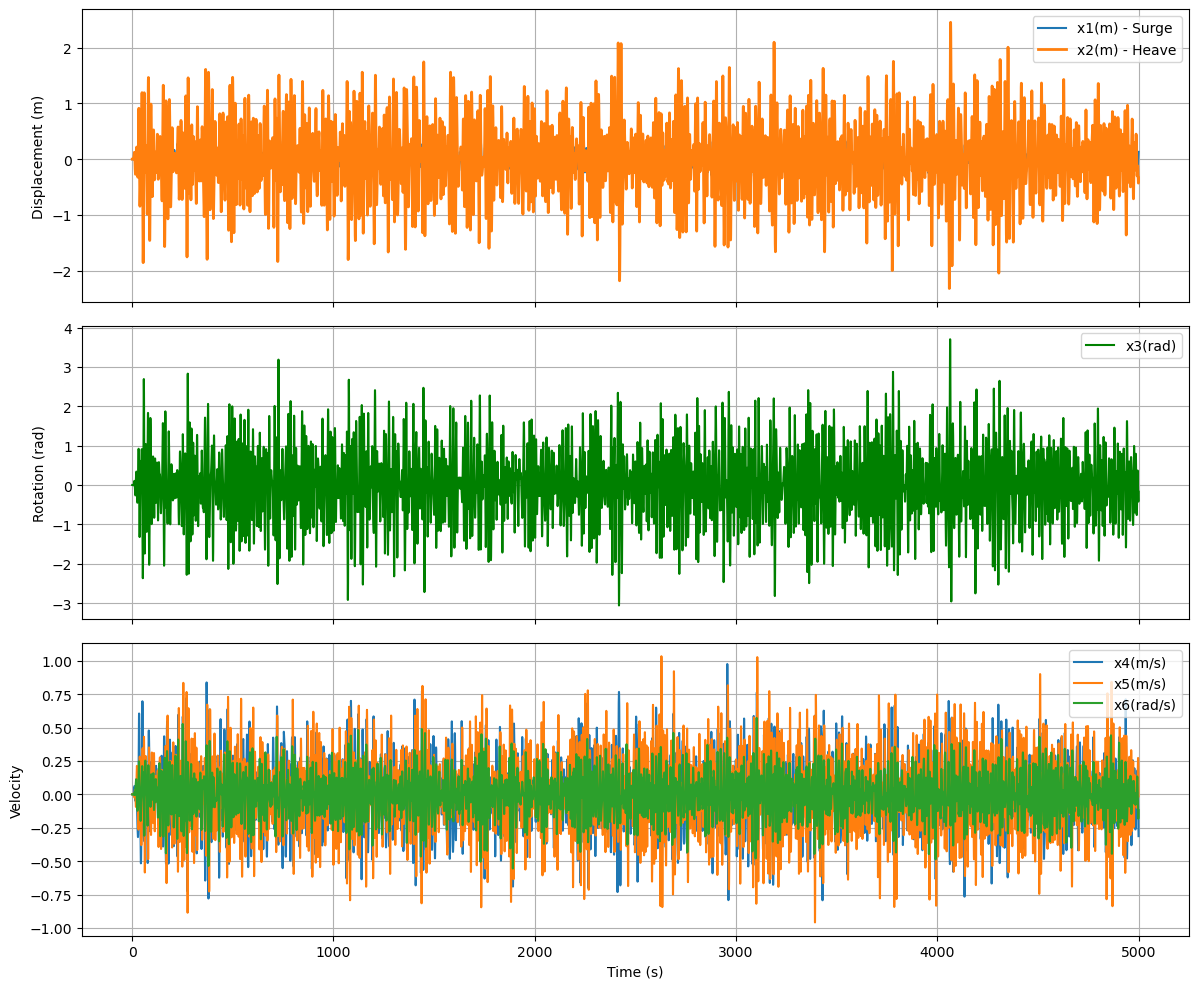

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. 파일 로딩 함수 (방금 제공된 코드의 핵심 로직 추출)
def test_load_single_file(file_path):
    column_names = ['t(s)', 'x1(m)', 'x2(m)', 'x3(rad)', 'x4(m/s)', 'x5(m/s)', 'x6(rad/s)']
    try:
        # 헤더 1줄 스킵, 공백 구분자 사용
        df = pd.read_csv(file_path, skiprows=1, sep='\s+', names=column_names, engine='python')
        return df
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

# 2. 경로 설정 (실제 파일명 하나를 지정하세요)
data_dir = "dataset_grid"
sample_file = "090_Tm_9.5_HS_3.5.out"  # 확인하고 싶은 파일명으로 변경
path = os.path.join(data_dir, sample_file)

# 3. 실행 및 시각화
df = test_load_single_file(path)

if df is not None:
    print(f"--- File: {sample_file} ---")
    print(df.head()) # 데이터 상단 출력
    
    # 그래프 그리기
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # (1) x1, x2 (Surge, Heave)
    axes[0].plot(df['t(s)'], df['x1(m)'], label='x1(m) - Surge')
    axes[0].plot(df['t(s)'], df['x2(m)'], label='x2(m) - Heave', linewidth=2)
    axes[0].set_ylabel('Displacement (m)')
    axes[0].legend()
    axes[0].grid(True)
    
    # (2) x3 (Pitch/Yaw 등 각도 데이터)
    axes[1].plot(df['t(s)'], df['x3(rad)'], color='green', label='x3(rad)')
    axes[1].set_ylabel('Rotation (rad)')
    axes[1].legend()
    axes[1].grid(True)
    
    # (3) x4, x5, x6 (속도 데이터)
    axes[2].plot(df['t(s)'], df['x4(m/s)'], label='x4(m/s)')
    axes[2].plot(df['t(s)'], df['x5(m/s)'], label='x5(m/s)')
    axes[2].plot(df['t(s)'], df['x6(rad/s)'], label='x6(rad/s)')
    axes[2].set_ylabel('Velocity')
    axes[2].set_xlabel('Time (s)')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("파일을 불러오지 못했습니다. 경로와 파일명을 다시 확인하세요.")

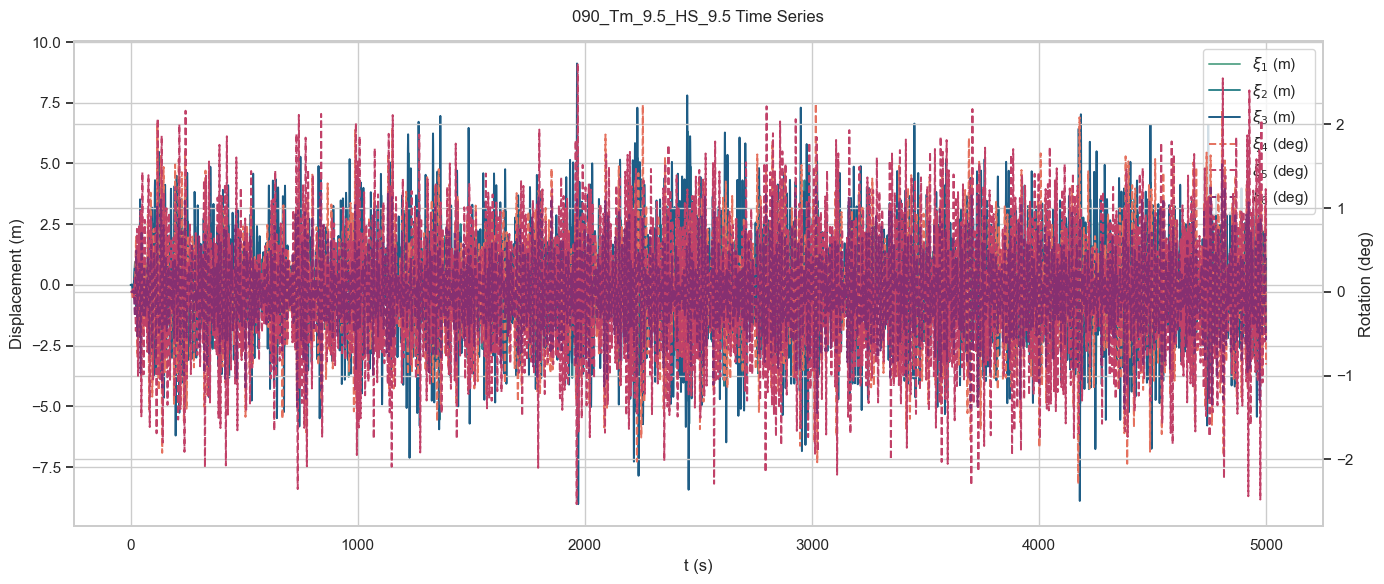

In [1]:
# Paste this whole cell into a Jupyter notebook code cell and run it.

from pathlib import Path
import html
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")

# OrcaFlex-style labels often use tags such as <greek>x</greek><sub>2</sub>.
# Convert them to matplotlib mathtext so Greek letters/subscripts render correctly.
GREEK_MATH_MAP = {
    "a": r"\alpha", "b": r"\beta", "c": r"\chi", "d": r"\delta",
    "e": r"\epsilon", "f": r"\phi", "g": r"\gamma", "h": r"\eta",
    "i": r"\iota", "j": r"\varphi", "k": r"\kappa", "l": r"\lambda",
    "m": r"\mu", "n": r"\nu", "o": r"o", "p": r"\pi",
    "q": r"\theta", "r": r"\rho", "s": r"\sigma", "t": r"\tau",
    "u": r"\upsilon", "v": r"\varpi", "w": r"\omega", "x": r"\xi",
    "y": r"\psi", "z": r"\zeta",
    "A": r"A", "B": r"B", "C": r"X", "D": r"\Delta",
    "E": r"E", "F": r"\Phi", "G": r"\Gamma", "H": r"H",
    "I": r"I", "J": r"\varPhi", "K": r"K", "L": r"\Lambda",
    "M": r"M", "N": r"N", "O": r"O", "P": r"\Pi",
    "Q": r"\Theta", "R": r"P", "S": r"\Sigma", "T": r"T",
    "U": r"\Upsilon", "V": r"\varPi", "W": r"\Omega", "X": r"\Xi",
    "Y": r"\Psi", "Z": r"Z",
}


def greek_to_mathtext(text: str) -> str:
    return "".join(GREEK_MATH_MAP.get(ch, ch) for ch in text)


def format_column_label(label: str) -> str:
    label = html.unescape(label)

    # Keep Greek symbols and their following subscript in one mathtext block.
    label = re.sub(
        r"<greek>(.*?)</greek>\s*<sub>(.*?)</sub>",
        lambda m: f"${greek_to_mathtext(m.group(1))}_{{{m.group(2)}}}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(
        r"<greek>(.*?)</greek>",
        lambda m: f"${greek_to_mathtext(m.group(1))}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(
        r"<sub>(.*?)</sub>",
        lambda m: f"$_{{{m.group(1)}}}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(r"<[^>]+>", "", label)
    return label.strip()


df = pd.read_csv(CSV_PATH)

# Keep the original data columns, but render plot labels from the first-row header cells.
time_col = df.columns[0]
left_cols = list(df.columns[1:4])   # columns 2, 3, 4: m
right_cols = list(df.columns[4:7])  # columns 5, 6, 7: deg
label_map = {col: format_column_label(col) for col in df.columns}

sns.set_theme(style="whitegrid", context="notebook")
fig, ax_left = plt.subplots(figsize=(14, 6))
ax_right = ax_left.twinx()

left_palette = sns.color_palette("crest", n_colors=len(left_cols))
right_palette = sns.color_palette("flare", n_colors=len(right_cols))

for col, color in zip(left_cols, left_palette):
    sns.lineplot(data=df, x=time_col, y=col, ax=ax_left, label=label_map[col], color=color, linewidth=1.4)

for col, color in zip(right_cols, right_palette):
    sns.lineplot(data=df, x=time_col, y=col, ax=ax_right, label=label_map[col], color=color, linewidth=1.4, linestyle="--")

ax_left.set_title("090_Tm_9.5_HS_9.5 Time Series", pad=14)
ax_left.set_xlabel(label_map[time_col])
ax_left.set_ylabel("Displacement (m)")
ax_right.set_ylabel("Rotation (deg)")

# Merge legends from the left and right axes into one legend.
left_handles, left_labels = ax_left.get_legend_handles_labels()
right_handles, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_handles + right_handles, left_labels + right_labels, loc="upper right", frameon=True)
if ax_right.get_legend() is not None:
    ax_right.get_legend().remove()

fig.tight_layout()
plt.show()


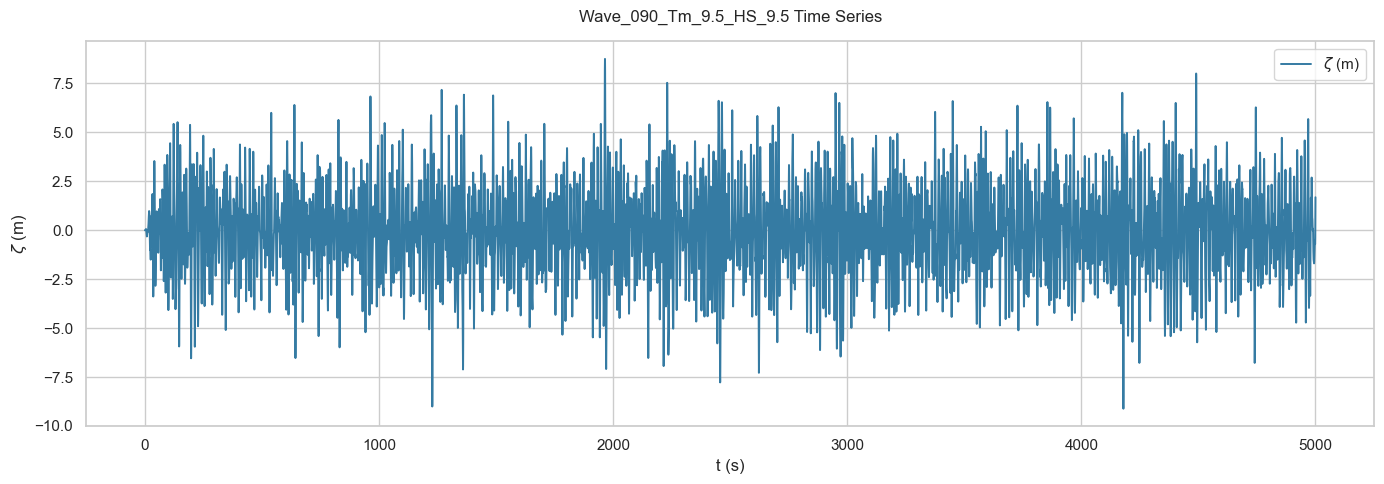

In [2]:
WAVE_CSV_PATH = Path("dataset_grid/Wave_090_Tm_9.5_HS_9.5.csv")

wave_df = pd.read_csv(WAVE_CSV_PATH)
wave_time_col = wave_df.columns[0]
wave_height_col = wave_df.columns[1]
wave_label_map = {col: format_column_label(col) for col in wave_df.columns}

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=wave_df,
    x=wave_time_col,
    y=wave_height_col,
    ax=ax,
    label=wave_label_map[wave_height_col],
    color=sns.color_palette("mako", n_colors=3)[1],
    linewidth=1.4,
)

ax.set_title("Wave_090_Tm_9.5_HS_9.5 Time Series", pad=14)
ax.set_xlabel(wave_label_map[wave_time_col])
ax.set_ylabel(wave_label_map[wave_height_col])
ax.legend(loc="upper right", frameon=True)

fig.tight_layout()
plt.show()


## 2. TimesNet(TimeCNN)

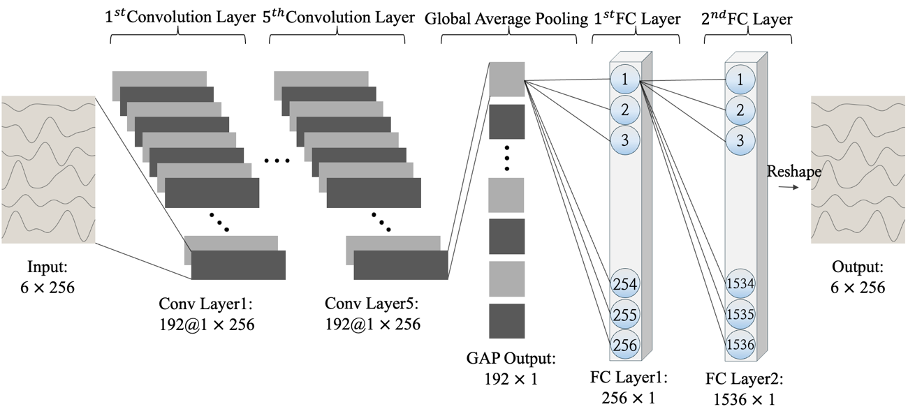

모델 로드 완료
사용 컬럼: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
입력 shape: (256, 6)
예측 shape: (256, 6)


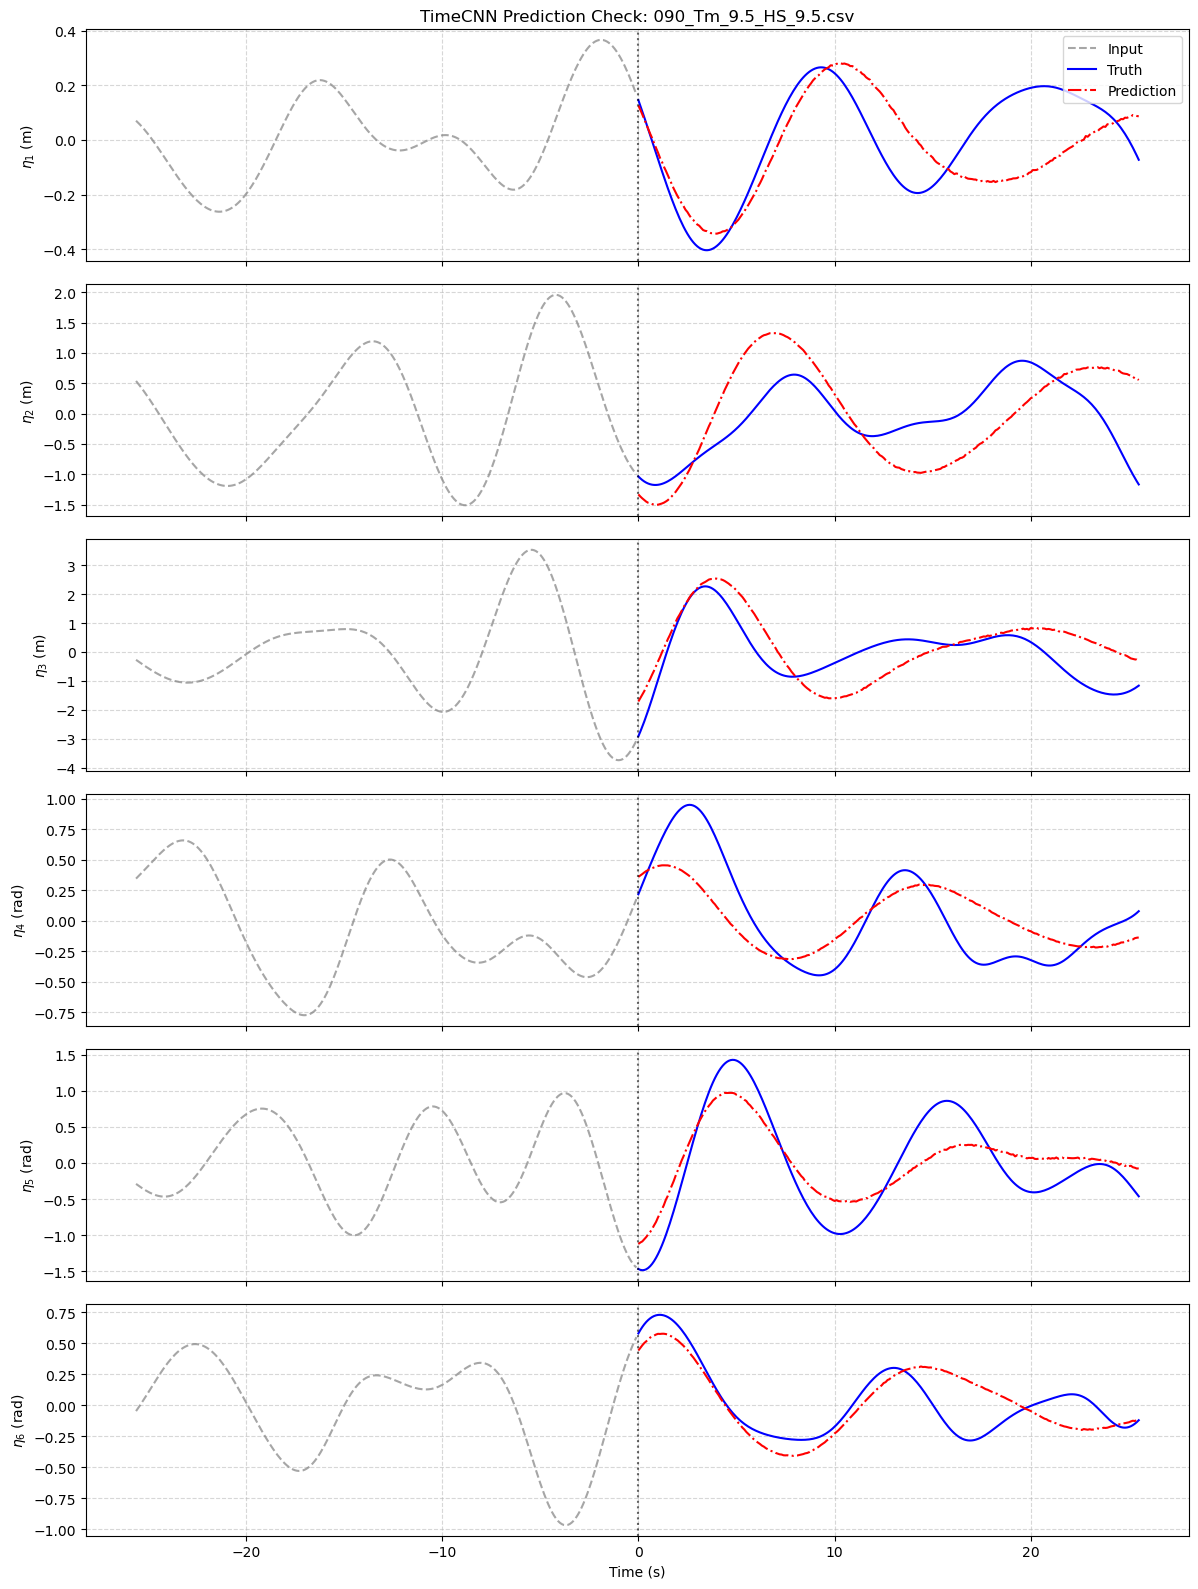

In [10]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# 1. 모델 클래스 정의
# ==============================
class FlexibleTimeCNN(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=64,
        kernel_sizes=None,
        use_bn=True,
        dropout=0.0,
    ):
        super().__init__()

        self.layers = nn.ModuleList()
        for i, ks in enumerate(kernel_sizes):
            padding = ks // 2
            in_ch = in_dof if i == 0 else channels

            conv = nn.Conv1d(
                in_channels=in_ch,
                out_channels=channels,
                kernel_size=ks,
                stride=1,
                padding=padding,
            )
            bn = nn.BatchNorm1d(channels) if use_bn else nn.Identity()
            self.layers.append(nn.Sequential(conv, bn, nn.ReLU()))

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        for block in self.layers:
            x = block(x)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        return x

class TimeCNNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        cnn_channels=64,
        kernel_sizes=None,
        conv_use_bn=True,
        conv_dropout=0.0,
    ):
        super().__init__()
        self.out_dof = out_dof
        self.out_len = out_len

        self.cnn = FlexibleTimeCNN(
            in_dof=in_dof,
            channels=cnn_channels,
            kernel_sizes=kernel_sizes,
            use_bn=conv_use_bn,
            dropout=conv_dropout,
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(cnn_channels, 256),
            nn.ReLU(),
            nn.Linear(256, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, src):
        x = self.cnn(src)
        x = x.permute(0, 2, 1)
        x = self.global_pool(x)
        x = self.fc(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

# ==============================
# 2. 모델 로드
# ==============================
MODEL_PATH = "models_TimeCNN/timecnn_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
dof_cols = checkpoint["dof_cols"]
time_col = checkpoint["time_col"]
data_min = checkpoint["data_min"]
data_range = checkpoint["data_range"]

model = TimeCNNRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    cnn_channels=model_config["cnn_channels"],
    kernel_sizes=model_config["kernel_sizes"],
    conv_use_bn=model_config["conv_use_bn"],
    conv_dropout=model_config["conv_dropout"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("사용 컬럼:", dof_cols)

# ==============================
# 3. 예측 대상 데이터 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

# 예시: 시작 위치 지정
start_idx = 210

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN 길이가 데이터보다 깁니다.")

# 입력/정답 구간
x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

# 스케일링
x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

# 역스케일링
y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)

# ==============================
# 4. 결과 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    
    ax.set_ylabel(latex_labels[i]) 
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"TimeCNN Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. ModernTCN
  - 입력 텐서는 (B, T, C) = (B, 256, 6) 형태이며 내부적으로 Conv1d 연산을 위해 (B, C, T)로 변환됨
  - 입력 단계에서 stem convolution을 통해 6채널 입력을 128채널 feature space로 확장하며 kernel size는 7이고 padding으로 길이를 유지함
  - backbone은 동일 구조의 ModernTCN block을 6개 stacked한 형태로 구성됨
  - 각 block은 depthwise convolution을 사용하며 groups=channels 설정으로 채널별 독립적인 temporal filtering 수행
  - depthwise convolution 이후 Channel-wise LayerNorm을 적용하여 안정적인 feature 정규화 수행
  - pointwise convolution(1×1 conv)을 통해 채널 간 정보 mixing 수행
  - activation function으로 GELU를 사용하여 비선형 표현력 향상
  - dropout이 block 내부에 포함되어 regularization 수행
  - 각 block은 residual connection을 포함하여 깊은 네트워크에서도 gradient 흐름을 안정화
  - dilation은 사용하지 않으며 receptive field는 kernel size와 block depth에 의해 선형적으로 증가
  - backbone 출력은 (B, T, C) 형태를 유지하며 시간축 정보를 보존
  - global average pooling을 통해 시간 차원을 (B, C, 1)로 축소하여 전체 시계열 정보를 압축
  - fully connected head는 flattened feature를 받아 hidden layer(256 units)를 거쳐 최종 출력 생성
  - 출력층은 (B, OUT_LEN × DOF) 형태를 생성한 후 (B, 256, 6)으로 reshape

Using device: cuda:0
cuDNN enabled: False
모델 로드 완료
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
model_type: ModernTCN
입력 shape: (256, 6)
예측 shape: (256, 6)


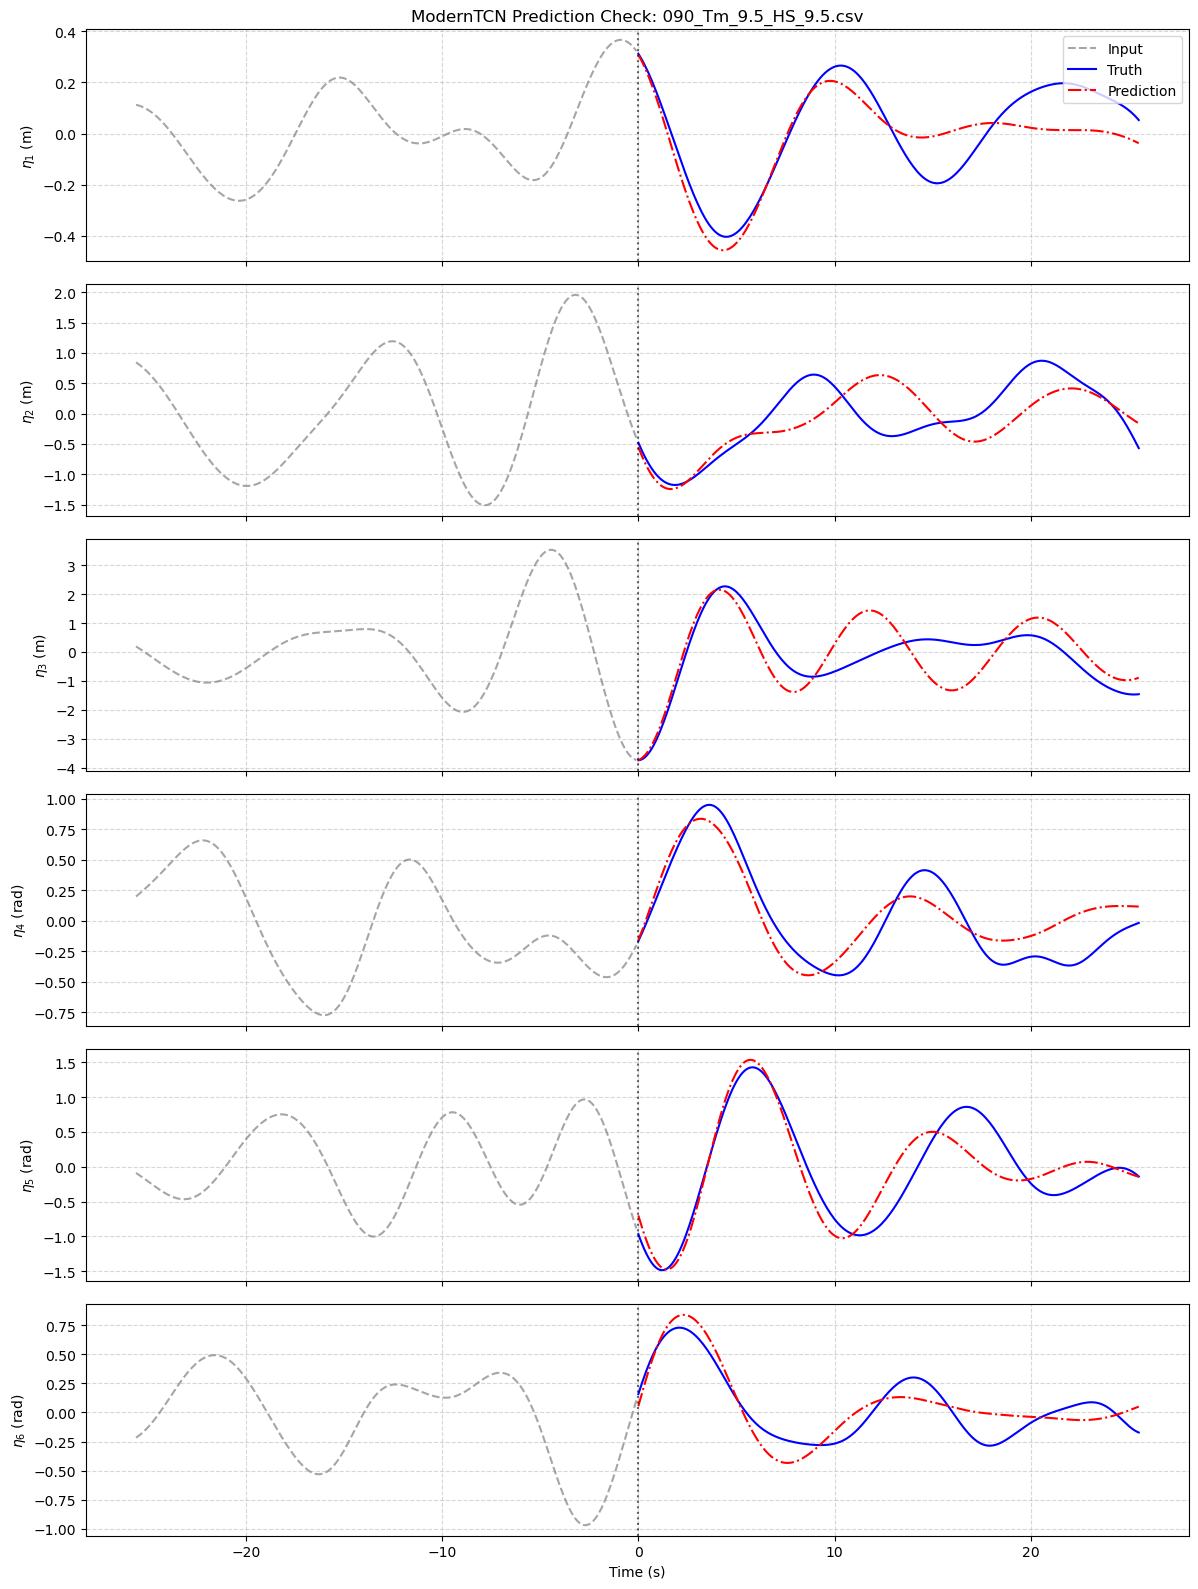

In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda Auto 환경 라이브러리를 우선 사용해 CUDA/cuDNN 충돌을 줄인다.
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

# ==============================
# 1. ModernTCN 정의
# ==============================
class PermuteToChannelsFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class PermuteToTimeFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

class ModernTCNBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, expansion=2.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(channels * expansion)
        padding = kernel_size // 2

        self.dwconv = nn.Conv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=True,
        )

        self.norm = ChannelLayerNorm(channels)

        self.pwffn = nn.Sequential(
            nn.Conv1d(channels, hidden_dim, kernel_size=1, bias=True),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, channels, kernel_size=1, bias=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwffn(x)
        x = x + residual
        return x

class ModernTCNBackbone(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        stem_padding = stem_kernel_size // 2

        self.input_proj = nn.Sequential(
            PermuteToChannelsFirst(),
            nn.Conv1d(in_dof, channels, kernel_size=stem_kernel_size, padding=stem_padding, bias=True),
        )

        self.blocks = nn.ModuleList([
            ModernTCNBlock(
                channels=channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

        self.out_permute = PermuteToTimeFirst()

    def forward(self, x):
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        x = self.out_permute(x)
        return x

class ModernTCNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_hidden_dim=256,
    ):
        super().__init__()

        self.out_len = out_len
        self.out_dof = out_dof

        self.backbone = ModernTCNBackbone(
            in_dof=in_dof,
            channels=channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, src):
        x = self.backbone(src)
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_ModernTCN/moderntcn_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = ModernTCNRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    channels=model_config["channels"],
    num_blocks=model_config["num_blocks"],
    kernel_size=model_config["kernel_size"],
    expansion=model_config["expansion"],
    dropout=model_config["dropout"],
    stem_kernel_size=model_config["stem_kernel_size"],
    head_hidden_dim=model_config["head_hidden_dim"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("model_type:", model_config["model_type"])

# ==============================
# 3. 예측 대상 CSV 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

# 예측 시작 인덱스
start_idx = 200

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN이 데이터 길이를 초과합니다.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

# min-max scaling
x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

# inverse scaling
y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)

# ==============================
# 4. 결과 시각화 (수정본)
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

# 0.1초 단위 샘플링을 고려한 시간축 생성
sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    
    ax.set_ylabel(latex_labels[i]) 
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"ModernTCN Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. CDCIHybrid

Using device: cuda:0
cuDNN enabled: False
모델 로드 완료
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
channel_groups: [['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)'], ['<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']]
입력 shape: (256, 6)
예측 shape: (256, 6)


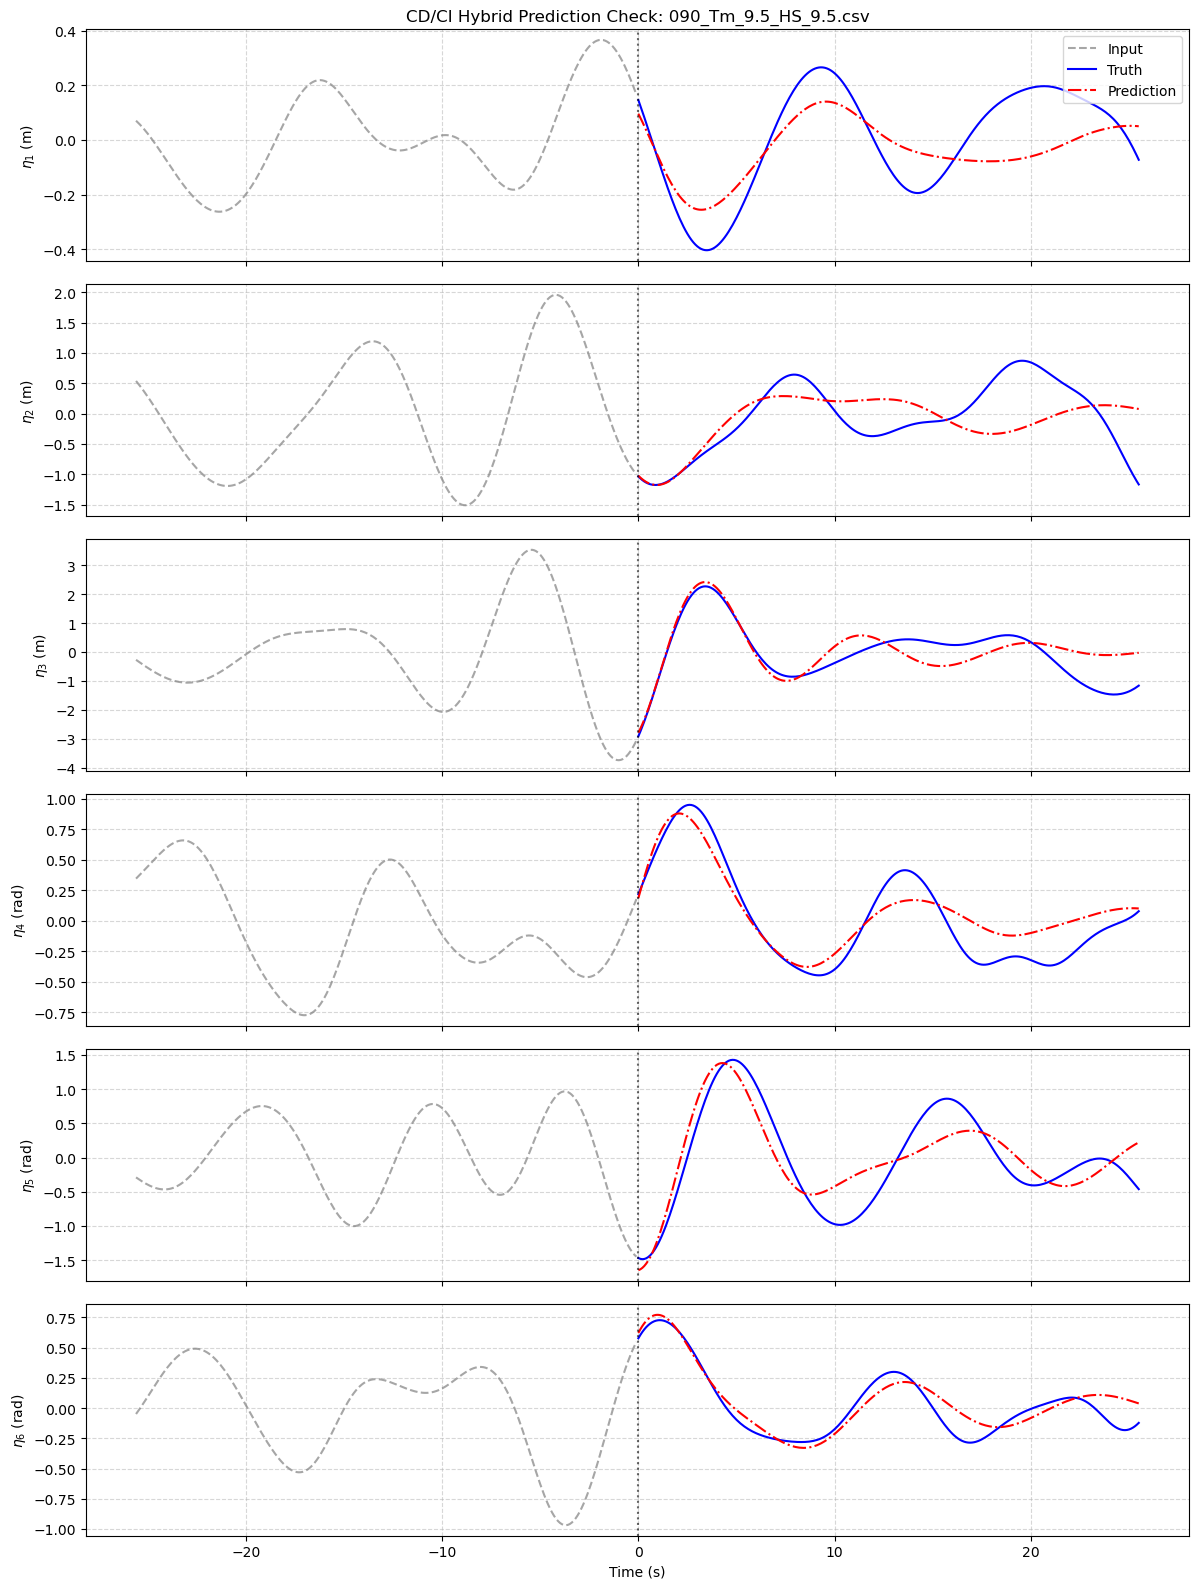

In [11]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda Auto 환경 라이브러리를 우선 사용해 CUDA/cuDNN 충돌을 줄인다.
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

# ==============================
# 1. 모델 정의
# ==============================
class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

class SharedClusterBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, expansion=2.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(channels * expansion)
        padding = kernel_size // 2

        self.dwconv = nn.Conv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=True,
        )
        self.norm = ChannelLayerNorm(channels)
        self.ffn = nn.Sequential(
            nn.Conv1d(channels, hidden_dim, kernel_size=1, bias=True),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, channels, kernel_size=1, bias=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.ffn(x)
        x = x + residual
        return x

class SharedClusterEncoder(nn.Module):
    def __init__(
        self,
        cluster_size=3,
        hidden_channels=96,
        num_blocks=5,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        stem_padding = stem_kernel_size // 2

        self.input_proj = nn.Conv1d(
            in_channels=cluster_size,
            out_channels=hidden_channels,
            kernel_size=stem_kernel_size,
            padding=stem_padding,
            bias=True,
        )

        self.blocks = nn.ModuleList([
            SharedClusterBlock(
                channels=hidden_channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        x = x.transpose(1, 2)
        return x

class SharedClusterHead(nn.Module):
    def __init__(
        self,
        hidden_channels=96,
        out_len=256,
        cluster_size=3,
        head_hidden_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        self.out_len = out_len
        self.cluster_size = cluster_size
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * cluster_size),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.cluster_size)
        return x

class CDCIHybridRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        channel_groups=None,
        hidden_channels=96,
        num_blocks=5,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_hidden_dim=256,
    ):
        super().__init__()

        if channel_groups is None:
            channel_groups = [[0, 1, 2], [3, 4, 5]]

        self.out_len = out_len
        self.out_dof = out_dof
        self.channel_groups = channel_groups

        group_sizes = [len(g) for g in channel_groups]
        self.cluster_size = group_sizes[0]

        self.shared_encoder = SharedClusterEncoder(
            cluster_size=self.cluster_size,
            hidden_channels=hidden_channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.shared_head = SharedClusterHead(
            hidden_channels=hidden_channels,
            out_len=out_len,
            cluster_size=self.cluster_size,
            head_hidden_dim=head_hidden_dim,
            dropout=dropout,
        )

    def forward(self, src):
        batch_size = src.size(0)
        pred_full = src.new_zeros((batch_size, self.out_len, self.out_dof))

        for group in self.channel_groups:
            x_group = src[:, :, group]
            z_group = self.shared_encoder(x_group)
            y_group = self.shared_head(z_group)
            pred_full[:, :, group] = y_group

        return pred_full

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_CDCIHybrid/cdcihybrid_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = CDCIHybridRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    channel_groups=model_config["channel_groups"],
    hidden_channels=model_config["hidden_channels"],
    num_blocks=model_config["num_blocks"],
    kernel_size=model_config["kernel_size"],
    expansion=model_config["expansion"],
    dropout=model_config["dropout"],
    stem_kernel_size=model_config["stem_kernel_size"],
    head_hidden_dim=model_config["head_hidden_dim"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("channel_groups:", model_config["channel_group_names"])

# ==============================
# 3. 예측 대상 CSV 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

start_idx = 210

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN이 데이터 길이를 초과합니다.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)

# ==============================
# 4. 결과 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(latex_labels[i])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"CD/CI Hybrid Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. SRADecider

Using device: cuda:0
cuDNN enabled: False
모델 로드 완료
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
model_type: SRADeciderHybrid
입력 shape: (256, 6)
예측 shape: (256, 6)
SRA score: 0.341066
CD gate weight: 0.455449
CI gate weight: 0.544551


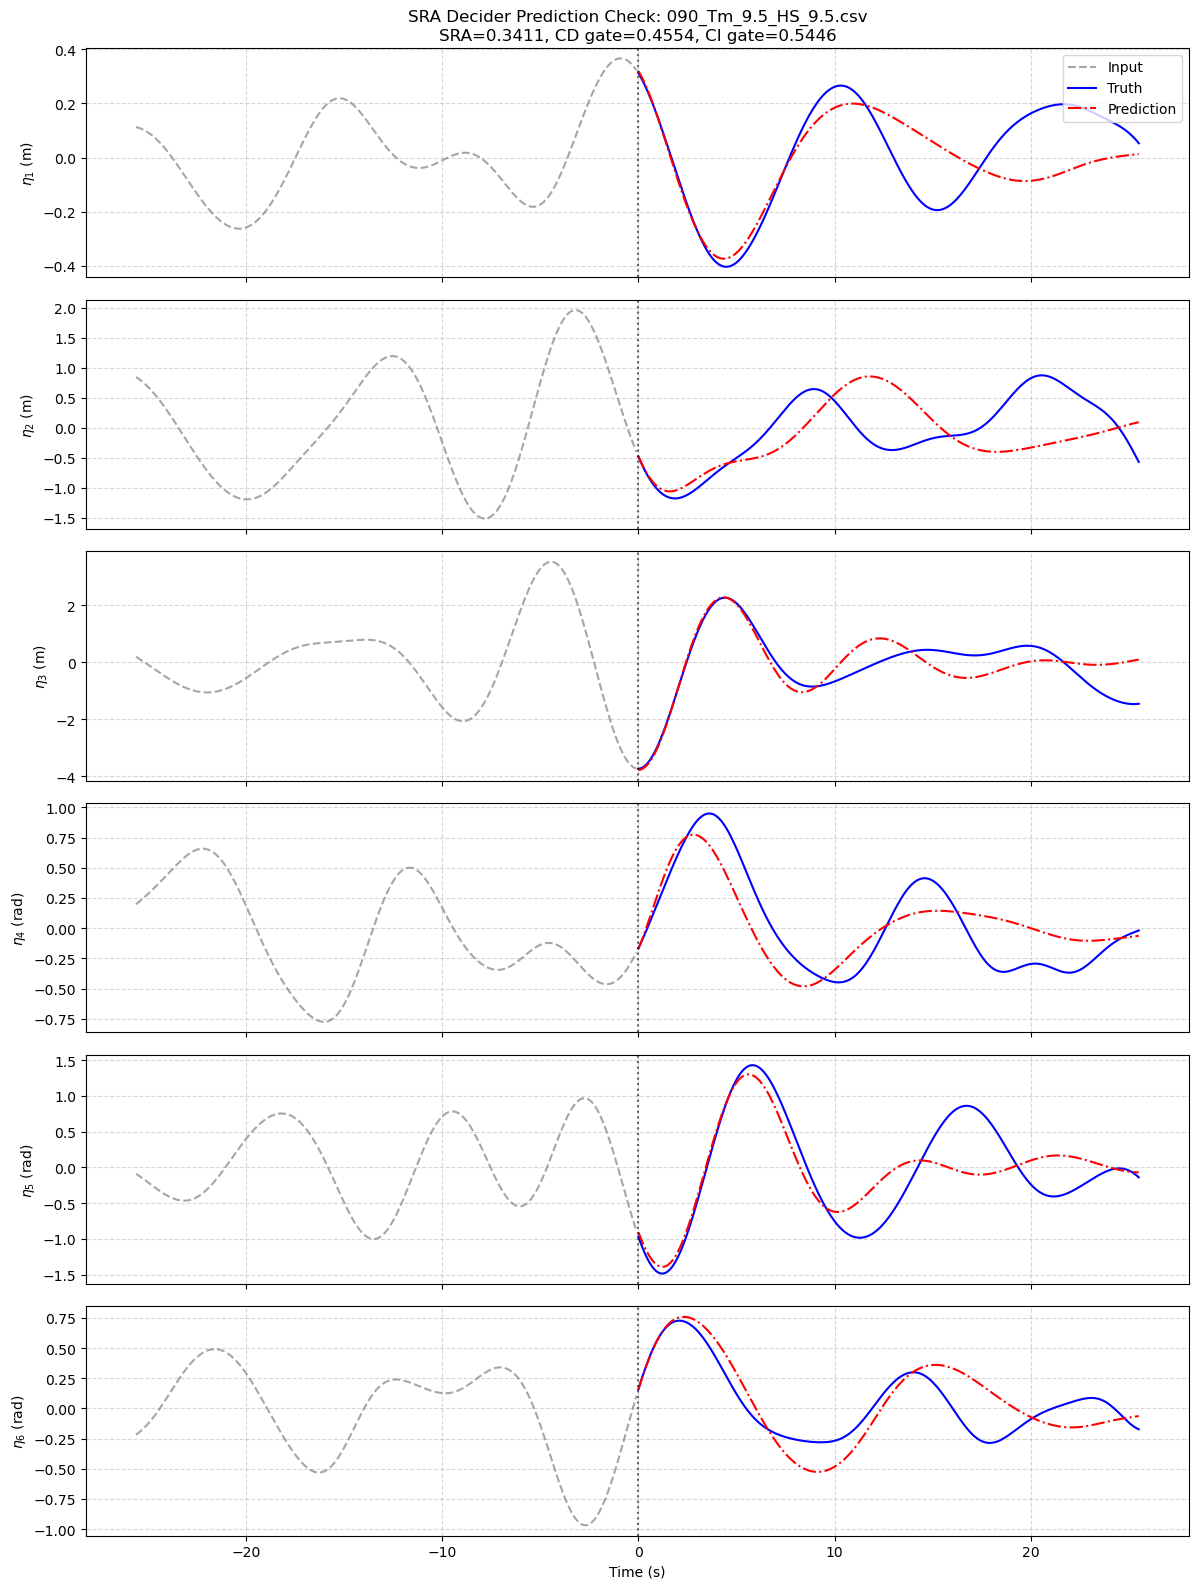

In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda Auto 환경 라이브러리를 우선 사용해 CUDA/cuDNN 충돌을 줄인다.
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

# ==============================
# 1. 모델 정의
# ==============================
class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

def torch_rankdata(x: torch.Tensor) -> torch.Tensor:
    order = torch.argsort(x, dim=1)
    ranks = torch.argsort(order, dim=1).float()
    return ranks

def batch_spearman_mean_abs_offdiag(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    B, T, C = x.shape
    ranks = torch_rankdata(x)
    ranks = ranks - ranks.mean(dim=1, keepdim=True)
    std = torch.sqrt((ranks ** 2).mean(dim=1, keepdim=True) + eps)
    z = ranks / std
    corr = torch.matmul(z.transpose(1, 2), z) / T

    eye = torch.eye(C, device=x.device).unsqueeze(0)
    offdiag_mask = 1.0 - eye
    abs_offdiag = corr.abs() * offdiag_mask
    denom = C * (C - 1)

    score = abs_offdiag.sum(dim=(1, 2)) / denom
    return score

class CISharedEncoder(nn.Module):
    def __init__(self, hidden_channels=64, num_blocks=4, kernel_size=31, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.stem = nn.Conv1d(1, hidden_channels, kernel_size=7, padding=3, bias=True)

        blocks = []
        for _ in range(num_blocks):
            blocks.append(nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size,
                          padding=padding, groups=hidden_channels, bias=True),
                ChannelLayerNorm(hidden_channels),
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(),
                nn.Dropout(dropout),
            ))
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        B, T, C = x.shape
        x = x.permute(0, 2, 1).contiguous()
        x = x.view(B * C, 1, T)

        x = self.stem(x)
        for block in self.blocks:
            residual = x
            x = block(x)
            x = x + residual

        x = x.transpose(1, 2)
        hidden = x.size(-1)
        x = x.view(B, C, T, hidden)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x

class CISharedHead(nn.Module):
    def __init__(self, hidden_channels=64, out_len=256, head_hidden_dim=128, dropout=0.1):
        super().__init__()
        self.out_len = out_len
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len),
            nn.Sigmoid(),
        )

    def forward(self, x):
        B, T, C, H = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(B * C, H, T)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(B, C, self.out_len)
        x = x.permute(0, 2, 1).contiguous()
        return x

class CDEncoder(nn.Module):
    def __init__(self, in_dof=6, hidden_channels=128, num_blocks=5, kernel_size=31, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.stem = nn.Conv1d(in_dof, hidden_channels, kernel_size=7, padding=3, bias=True)

        blocks = []
        for _ in range(num_blocks):
            blocks.append(nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size,
                          padding=padding, groups=1, bias=True),
                ChannelLayerNorm(hidden_channels),
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(),
                nn.Dropout(dropout),
            ))
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.stem(x)
        for block in self.blocks:
            residual = x
            x = block(x)
            x = x + residual
        x = x.transpose(1, 2)
        return x

class CDHead(nn.Module):
    def __init__(self, hidden_channels=128, out_len=256, out_dof=6, head_hidden_dim=256, dropout=0.1):
        super().__init__()
        self.out_len = out_len
        self.out_dof = out_dof
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

class SRADeciderHybridRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        ci_hidden_channels=64,
        ci_num_blocks=4,
        cd_hidden_channels=128,
        cd_num_blocks=5,
        kernel_size=31,
        dropout=0.1,
        ci_head_hidden_dim=128,
        cd_head_hidden_dim=256,
        sra_threshold=0.35,
        sra_temperature=0.05,
    ):
        super().__init__()

        self.out_len = out_len
        self.out_dof = out_dof
        self.sra_threshold = float(sra_threshold)
        self.sra_temperature = float(sra_temperature)

        self.ci_encoder = CISharedEncoder(
            hidden_channels=ci_hidden_channels,
            num_blocks=ci_num_blocks,
            kernel_size=kernel_size,
            dropout=dropout,
        )
        self.ci_head = CISharedHead(
            hidden_channels=ci_hidden_channels,
            out_len=out_len,
            head_hidden_dim=ci_head_hidden_dim,
            dropout=dropout,
        )

        self.cd_encoder = CDEncoder(
            in_dof=in_dof,
            hidden_channels=cd_hidden_channels,
            num_blocks=cd_num_blocks,
            kernel_size=kernel_size,
            dropout=dropout,
        )
        self.cd_head = CDHead(
            hidden_channels=cd_hidden_channels,
            out_len=out_len,
            out_dof=out_dof,
            head_hidden_dim=cd_head_hidden_dim,
            dropout=dropout,
        )

    def compute_gate(self, src):
        sra_score = batch_spearman_mean_abs_offdiag(src)
        gate = torch.sigmoid((sra_score - self.sra_threshold) / self.sra_temperature)
        gate = gate.view(-1, 1, 1)
        return gate, sra_score

    def forward(self, src, return_gate=False):
        ci_feat = self.ci_encoder(src)
        ci_out = self.ci_head(ci_feat)

        cd_feat = self.cd_encoder(src)
        cd_out = self.cd_head(cd_feat)

        gate, sra_score = self.compute_gate(src)
        out = gate * cd_out + (1.0 - gate) * ci_out

        if return_gate:
            return out, gate.squeeze(-1).squeeze(-1), sra_score
        return out

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_SRADecider/sra_decider_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = SRADeciderHybridRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    ci_hidden_channels=model_config["ci_hidden_channels"],
    ci_num_blocks=model_config["ci_num_blocks"],
    cd_hidden_channels=model_config["cd_hidden_channels"],
    cd_num_blocks=model_config["cd_num_blocks"],
    kernel_size=model_config["kernel_size"],
    dropout=model_config["dropout"],
    ci_head_hidden_dim=model_config["ci_head_hidden_dim"],
    cd_head_hidden_dim=model_config["cd_head_hidden_dim"],
    sra_threshold=model_config["sra_threshold"],
    sra_temperature=model_config["sra_temperature"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("model_type:", model_config["model_type"])

# ==============================
# 3. 예측 대상 CSV 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

start_idx = 200

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN이 데이터 길이를 초과합니다.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled, gate_val, sra_score = model(x_tensor, return_gate=True)
    y_pred_scaled = y_pred_scaled.squeeze(0).cpu().numpy()
    gate_val = gate_val.item()
    sra_score = sra_score.item()

y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)
print(f"SRA score: {sra_score:.6f}")
print(f"CD gate weight: {gate_val:.6f}")
print(f"CI gate weight: {1.0 - gate_val:.6f}")

# ==============================
# 4. 결과 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(latex_labels[i])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(
    f"SRA Decider Prediction Check: {CSV_PATH.name}\n"
    f"SRA={sra_score:.4f}, CD gate={gate_val:.4f}, CI gate={1.0-gate_val:.4f}"
)
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()